# Trigrams and the sparsity experiment
**Episode 02B · Build a language model with more context**

In the theory episode, we saw why more specific questions can have less evidence.
Now we build the model and measure the tradeoff. Start with `anna` and `ava`,
then use the same names dataset and split as Episode 01.

**What you will build:** arbitrary-length context windows, sparse counts,
on-demand smoothing, evaluation, generation, and an experiment comparing 1–5
context characters. The implementation below is visible, standard-library Python;
Matplotlib only draws the charts.

Run from top to bottom. Download the **whole repository**, not this notebook alone.
The [code guide](CODE_GUIDE.md) explains setup; the [theory guide](../../docs/episode-02-theory.pdf)
supplies the math. Charts and reproducibility reports are written into `outputs/`.

## 1 · Setup and the smallest training set
Keep setup prepared when recording. Our next-token vocabulary is `a, n, v, END`.
START is context only. Later we will learn the real vocabulary from training data.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import hashlib
import json
import math
import platform
import random
import sys

# Works from the repository root or this episode folder.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "episodes/02_trigrams/lab.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open the whole llm-from-scratch repository first.")
EPISODE = ROOT / "episodes/02_trigrams"
DATA = ROOT / "episodes/01_names/data"
OUTPUT = EPISODE / "outputs"
OUTPUT.mkdir(exist_ok=True)
sys.path.insert(0, str(EPISODE))
from visuals import setup, plot_losses, plot_evidence, plot_sweep
setup()

START, END = "<START>", "<END>"
toy_names = ["anna", "ava"]
print("Python:", platform.python_version())
print("Training names:", toy_names)

Python: 3.14.2
Training names: ['anna', 'ava']


## 2 · Build windows, not just pairs
`context_size` means **previous characters**, so 2 means a trigram.
Pad with that many START tokens, predict one target, then slide one position.
The tuple can be a dictionary key; a list cannot. `yield` gives one example at a
time, and `list(...)` below collects the examples so we can inspect them.

In [2]:
def windows(name, context_size):
    """Yield (context tuple, target); START is context only, END is scored once."""
    if not isinstance(context_size, int) or context_size < 1:
        raise ValueError("context_size must be a positive integer")
    tokens = [START] * context_size + list(name) + [END]
    for index in range(context_size, len(tokens)):
        yield tuple(tokens[index - context_size:index]), tokens[index]

In [3]:
for name in toy_names:
    print(name)
    for context, target in windows(name, 2):
        print(" ", context, "->", target)
for m in range(1, 6):
    total = sum(1 for name in toy_names for _ in windows(name, m))
    assert total == 9
    print(f"m={m}: {total} predictions")

anna
  ('<START>', '<START>') -> a
  ('<START>', 'a') -> n
  ('a', 'n') -> n
  ('n', 'n') -> a
  ('n', 'a') -> <END>
ava
  ('<START>', '<START>') -> a
  ('<START>', 'a') -> v
  ('a', 'v') -> a
  ('v', 'a') -> <END>
m=1: 9 predictions
m=2: 9 predictions
m=3: 9 predictions
m=4: 9 predictions
m=5: 9 predictions


## 3 · Count observed rows and answer probability queries
A `CountModel` keeps the context size, allowed outcomes, counts, and row totals together.
`defaultdict(Counter)` creates a count row during training. Each inner Counter maps
a target to its count. At prediction time, `.get()` reads a missing count as zero
**without inserting it** into the training dictionary.

Read the class in two passes: first `__init__` (training), then `probability` (lookup).
`self` means this particular model. The probability formula is the same as Episode 01:

$$P_k(t\mid h)=\frac{C(h,t)+k}{C(h)+kK}.$$

`None` marks an unspecified whole row at k = 0. It is different from probability zero.

In [4]:
class CountModel:
    def __init__(self, names, context_size):
        names = list(names)
        if not names or not any(names):
            raise ValueError("Training needs at least one ordinary character")
        # Also validates the context length before constructing a model.
        list(windows("", context_size))
        self.context_size = context_size
        self.outcomes = tuple(sorted(set("".join(names)))) + (END,)
        self.counts = defaultdict(Counter)
        for name in names:
            for context, target in windows(name, context_size):
                self.counts[context][target] += 1
        self.totals = {context: sum(row.values())
                       for context, row in self.counts.items()}

    def probability(self, context, target, k=0.0):
        if not math.isfinite(k) or k < 0:
            raise ValueError("k must be finite and non-negative")
        context = tuple(context)
        if len(context) != self.context_size:
            raise ValueError("Wrong context length")
        if target not in self.outcomes:
            raise ValueError(f"Unknown target: {target}")
        # get() deliberately avoids adding evaluation contexts to the counts.
        count = self.counts.get(context, {}).get(target, 0)
        total = self.totals.get(context, 0)
        if total == 0 and k == 0:
            return None  # 0/0: MLE leaves this entire row unspecified.
        return (count + k) / (total + k * len(self.outcomes))

In [5]:
bigram = CountModel(toy_names, 1)
trigram = CountModel(toy_names, 2)
from pprint import pprint

print("Actual sparse storage: only observed context-target counts")
pprint(trigram.counts, sort_dicts=False, width=100)
print()
print("Table view: missing entries displayed as 0 (not added to storage)")
print("Context                 a   n   v END | total")
for context, row in trigram.counts.items():
    values = [row.get(t, 0) for t in trigram.outcomes]
    print(f"{str(context):23}", " ".join(f"{v:3}" for v in values),
          "|", trigram.totals[context])
assert len(trigram.counts) == 7
assert sum(trigram.totals.values()) == 9
stored_before = {context: dict(row) for context, row in trigram.counts.items()}

Actual sparse storage: only observed context-target counts
defaultdict(<class 'collections.Counter'>,
            {('<START>', '<START>'): Counter({'a': 2}),
             ('<START>', 'a'): Counter({'n': 1, 'v': 1}),
             ('a', 'n'): Counter({'n': 1}),
             ('n', 'n'): Counter({'a': 1}),
             ('n', 'a'): Counter({'<END>': 1}),
             ('a', 'v'): Counter({'a': 1}),
             ('v', 'a'): Counter({'<END>': 1})})

Table view: missing entries displayed as 0 (not added to storage)
Context                 a   n   v END | total
('<START>', '<START>')    2   0   0   0 | 2
('<START>', 'a')          0   1   1   0 | 2
('a', 'n')                0   1   0   0 | 1
('n', 'n')                1   0   0   0 | 1
('n', 'a')                0   0   0   1 | 1
('a', 'v')                1   0   0   0 | 1
('v', 'a')                0   0   0   1 | 1


## 4 · Evaluate supplied names
Feed in the real history, look up the actual target, add negative log probability,
and divide by the total number of predictions. Include one END per name.
Longer names contribute more predictions; this is not an unweighted mean of name losses.

An undefined row and a zero probability both prevent finite raw evaluation, so this
evaluator returns infinity as a failure marker while counting the two cases separately.
It does not pretend that `None` defines a zero-probability distribution.

In [6]:
def evaluate(model, names, k):
    loss = 0.0
    predictions = zero = unseen = 0
    for name in names:
        for context, target in windows(name, model.context_size):
            p = model.probability(context, target, k)
            predictions += 1
            unseen += int(context not in model.totals)
            zero += int(p == 0)
            # Infinity is a failure marker if any row is undefined, not a
            # claim that 0/0 defines a zero-probability distribution.
            loss += -math.log(p) if p is not None and p > 0 else math.inf
    if not predictions:
        raise ValueError("Evaluation needs at least one example")
    return {"nll": loss / predictions, "predictions": predictions,
            "zero_probability_predictions": zero,
            "unseen_context_predictions": unseen}

In [7]:
for label, model, k in [("Bigram", bigram, 0), ("Trigram", trigram, 0),
                        ("Trigram, add-one", trigram, 1)]:
    factors = [model.probability(c, t, k) for c, t in windows("ana", model.context_size)]
    result = evaluate(model, ["ana"], k)
    print(label, "| factors:", factors)
    print("  P(ana):", math.prod(factors), "|", result)
assert math.isclose(evaluate(bigram, ["ana"], 0)["nll"], math.log(16)/4)
assert math.isclose(evaluate(trigram, ["ana"], 1)["nll"], math.log(75)/4)
print("Trigram | avna:", evaluate(trigram, ["avna"], 0))
print("Trigram, add-one | avna:", evaluate(trigram, ["avna"], 1))
assert stored_before == {c: dict(row) for c, row in trigram.counts.items()}
print("Evaluation did not change the stored training counts.")

Bigram | factors: [1.0, 0.25, 0.5, 0.5]
  P(ana): 0.0625 | {'nll': 0.6931471805599453, 'predictions': 4, 'zero_probability_predictions': 0, 'unseen_context_predictions': 0}
Trigram | factors: [1.0, 0.5, 0.0, 1.0]
  P(ana): 0.0 | {'nll': inf, 'predictions': 4, 'zero_probability_predictions': 1, 'unseen_context_predictions': 0}
Trigram, add-one | factors: [0.5, 0.3333333333333333, 0.2, 0.4]
  P(ana): 0.013333333333333334 | {'nll': 1.0793720283840775, 'predictions': 4, 'zero_probability_predictions': 0, 'unseen_context_predictions': 0}
Trigram | avna: {'nll': inf, 'predictions': 5, 'zero_probability_predictions': 1, 'unseen_context_predictions': 1}
Trigram, add-one | avna: {'nll': 1.14075649493124, 'predictions': 5, 'zero_probability_predictions': 0, 'unseen_context_predictions': 1}
Evaluation did not change the stored training counts.


## 5 · Generate using the same probability function
Start with START padding; sample one token; keep the last m tokens.
`context[1:]` drops the oldest token and `(*context[1:], target)` appends the new one.
END means the model stopped. CAP means our loop stopped without predicting END.
Here the cap is **24 prediction steps**, including any END prediction.

In [8]:
def generate(model, k, rng, max_steps=24):
    context = (START,) * model.context_size
    letters = []
    for _ in range(max_steps):
        weights = [model.probability(context, token, k) for token in model.outcomes]
        if any(p is None for p in weights):
            raise ValueError("Generation reached an unspecified row; use k > 0")
        target = rng.choices(model.outcomes, weights=weights, k=1)[0]
        if target == END:
            return {"name": "".join(letters), "ended": True}
        letters.append(target)
        context = (*context[1:], target)
    return {"name": "".join(letters), "ended": False}

In [9]:
sample_count = 12

for k in (0, 1):
    rng = random.Random(2026)
    batch = [generate(trigram, k, rng) for _ in range(sample_count)]
    print(f"Toy trigram, k={k}: first {sample_count}, unfiltered")
    for sample in batch:
        print(repr(sample["name"]), "END" if sample["ended"] else "CAP")
    if k == 0:
        assert all(s["name"] in toy_names and s["ended"] for s in batch)
assert stored_before == {c: dict(row) for c, row in trigram.counts.items()}

Toy trigram, k=0: first 12, unfiltered
'ava' END
'anna' END
'ava' END
'anna' END
'ava' END
'anna' END
'ava' END
'anna' END
'anna' END
'ava' END
'ava' END
'anna' END
Toy trigram, k=1: first 12, unfiltered
'avn' END
'anvv' END
'nv' END
'vva' END
'avn' END
'vvan' END
'' END
'v' END
'nannav' END
'vva' END
'annnnavvvn' END
'an' END


Smoothing can generate unseen spellings, including empty strings because the initial
row can select END. Sampling more names does not train the model. A fixed seed makes
our reference run reproducible, but exact samples can depend on Python version.

## 6 · Load the same real data and splits as Episode 01
Deduplicate spellings before splitting to avoid an identical name in training and
evaluation. Sort before the seeded shuffle. Each unique spelling has equal weight;
these are not population-frequency counts. The checksum verifies the bundled source.

In [10]:
def load_splits():
    raw = (DATA / "names.txt").read_bytes()
    provenance = json.loads((DATA / "provenance.json").read_text())
    if hashlib.sha256(raw).hexdigest() != provenance["sha256"]:
        raise ValueError("Dataset checksum mismatch")
    names = sorted(set(raw.decode("utf-8").splitlines()))
    if not all(name and name.isascii() and name.isalpha() and name.islower() for name in names):
        raise ValueError("Expected nonempty lowercase ASCII names")
    random.Random(42).shuffle(names)
    train_end, val_end = int(0.8 * len(names)), int(0.9 * len(names))
    return names[:train_end], names[train_end:val_end], names[val_end:], provenance

In [11]:
train_names, validation_names, test_names, provenance = load_splits()
training_spellings = set(train_names)
assert training_spellings.isdisjoint(validation_names)
assert training_spellings.isdisjoint(test_names)
assert set(validation_names).isdisjoint(test_names)
for label, names in [("Training", train_names), ("Validation", validation_names), ("Test", test_names)]:
    print(f"{label:12} {len(names):6,} names | {sum(len(n)+1 for n in names):7,} predictions")
vocabulary = set("".join(train_names))
for label, names in [("Validation", validation_names), ("Test", test_names)]:
    unknown = set("".join(names)) - vocabulary
    if unknown:
        raise ValueError(f"{label} has unsupported characters: {sorted(unknown)}")
print(len(vocabulary), "training letters plus END; no held-out letters added.")

Training     23,595 names | 169,134 predictions
Validation    2,949 names |  21,141 predictions
Test          2,950 names |  21,053 predictions
26 training letters plus END; no held-out letters added.


## 7 · Declare the experiment, then train
Compare context lengths 1–5 (bigrams through 6-grams). Choose k separately for each
context using the same candidate grid, including k = 0 (no smoothing), then choose the context with lowest
validation NLL. Ties use the first candidate in the declared order.

This experiment was explored on validation while preparing the theory. It is a
reproducible demonstration, not a preregistered discovery. We include the original
positive grid plus k = 0, which was previously reported separately.
We will report every context's selected-k test score after freezing the choices,
without changing the validation-selected winner based on test results.

In [12]:
CONTEXT_SIZES = (1, 2, 3, 4, 5)
K_VALUES = (0, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0)
models = {m: CountModel(train_names, m) for m in CONTEXT_SIZES}
prediction_count = sum(len(n)+1 for n in train_names)
print("m | observed rows | singleton rows | training predictions")
for m, model in models.items():
    assert sum(model.totals.values()) == prediction_count
    singletons = sum(total == 1 for total in model.totals.values())
    print(f"{m} | {len(model.counts):13,} | {singletons:14,} | {sum(model.totals.values()):20,}")

m | observed rows | singleton rows | training predictions
1 |            27 |              0 |              169,134
2 |           592 |             57 |              169,134
3 |         5,402 |          1,197 |              169,134
4 |        20,067 |          8,581 |              169,134
5 |        36,171 |         21,379 |              169,134


## 8 · Choose smoothing with validation
Every candidate scores the same 21,141 validation targets, including k = 0 (no
smoothing). Choose the lowest validation NLL. Here, every k = 0 model encounters
zero-count targets or missing contexts, so its loss is infinite and it does not win.
A missing unsmoothed row has no defined distribution; we report infinity as a scoring
failure. On another dataset, k = 0 could win. No test losses are used here.

m=1  k=0.3  train=2.453138  val=2.456622


m=2  k=0.3  train=2.197541  val=2.233214


m=3  k=0.1  train=1.924842  val=2.126903


m=4  k=0.1  train=1.762922  val=2.196154


m=5  k=0.1  train=1.750099  val=2.386382
Validation-selected context: 3 k: 0.1


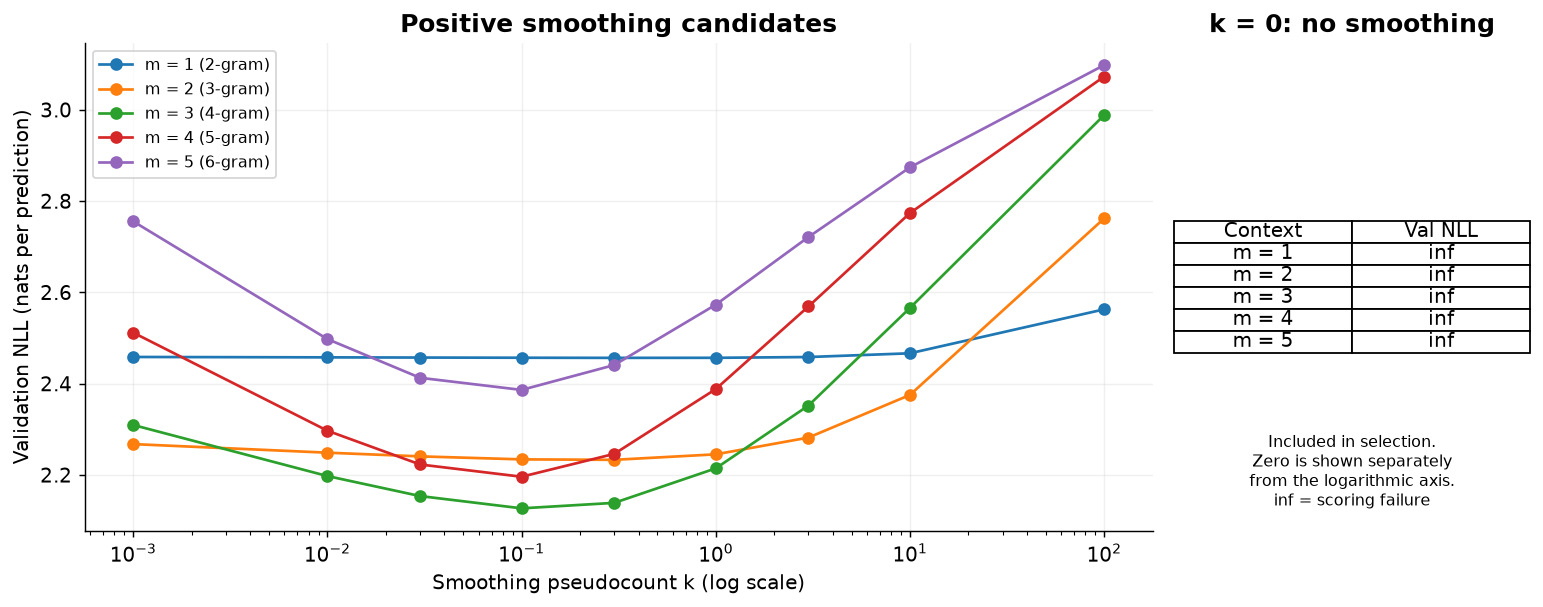

In [13]:
records = []
for m, model in models.items():
    sweep = [{"k": k, **evaluate(model, validation_names, k)} for k in K_VALUES]
    best = min(sweep, key=lambda r: r["nll"])
    record = {
        "context_size": m, "ngram_order": m+1,
        "selected_k": best["k"], "validation_sweep": sweep,
        "train": evaluate(model, train_names, best["k"]), "validation": best,
        "unsmoothed_train": evaluate(model, train_names, 0),
        "unsmoothed_validation": sweep[0],
        "observed_rows": len(model.counts),
        "observed_cells": sum(len(row) for row in model.counts.values()),
        "singleton_rows": sum(total == 1 for total in model.totals.values()),
        "possible_rows": sum(len(vocabulary)**j for j in range(m+1)),
    }
    records.append(record)
    raw = record["unsmoothed_validation"]
    # print(f"m={m}  k=0  val={raw['nll']:.6f}  zero-count targets={raw['zero_probability_predictions']}"
    #       f"  missing contexts={raw['unseen_context_predictions']}")
    print(f"m={m}  k={best['k']:g}  train={record['train']['nll']:.6f}  val={best['nll']:.6f}")
selected = min(records, key=lambda r: r["validation"]["nll"])
print("Validation-selected context:", selected["context_size"], "k:", selected["selected_k"])
plot_sweep(records, OUTPUT)

## 9 · Read the loss curves alongside the evidence
Selected-k training loss and raw training loss are different measurements.
The left panel labels both. The right panel holds k fixed so that changing selected
smoothing values cannot be mistaken for the entire context effect.

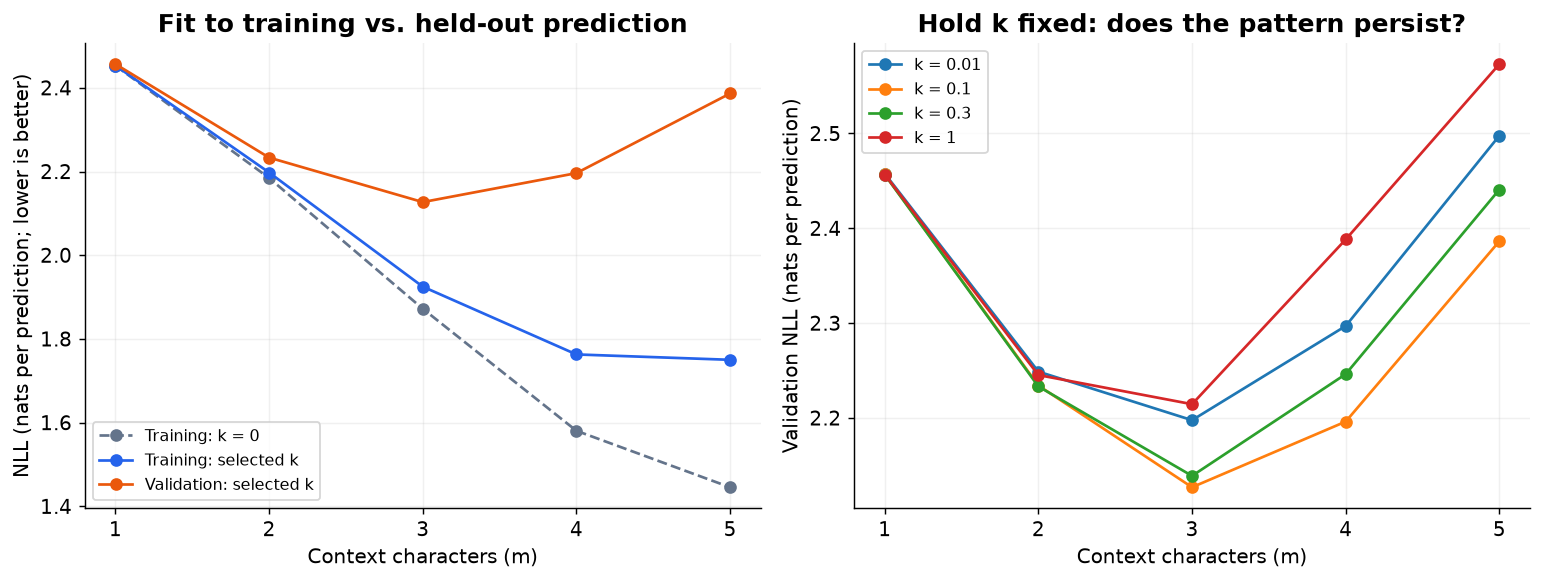

m | singleton rows / observed rows | unseen validation predictions / all predictions
1 | 0 / 27 | 0 / 21,141
2 | 57 / 592 | 8 / 21,141
3 | 1,197 / 5,402 | 176 / 21,141
4 | 8,581 / 20,067 | 1,153 / 21,141
5 | 21,379 / 36,171 | 2,746 / 21,141


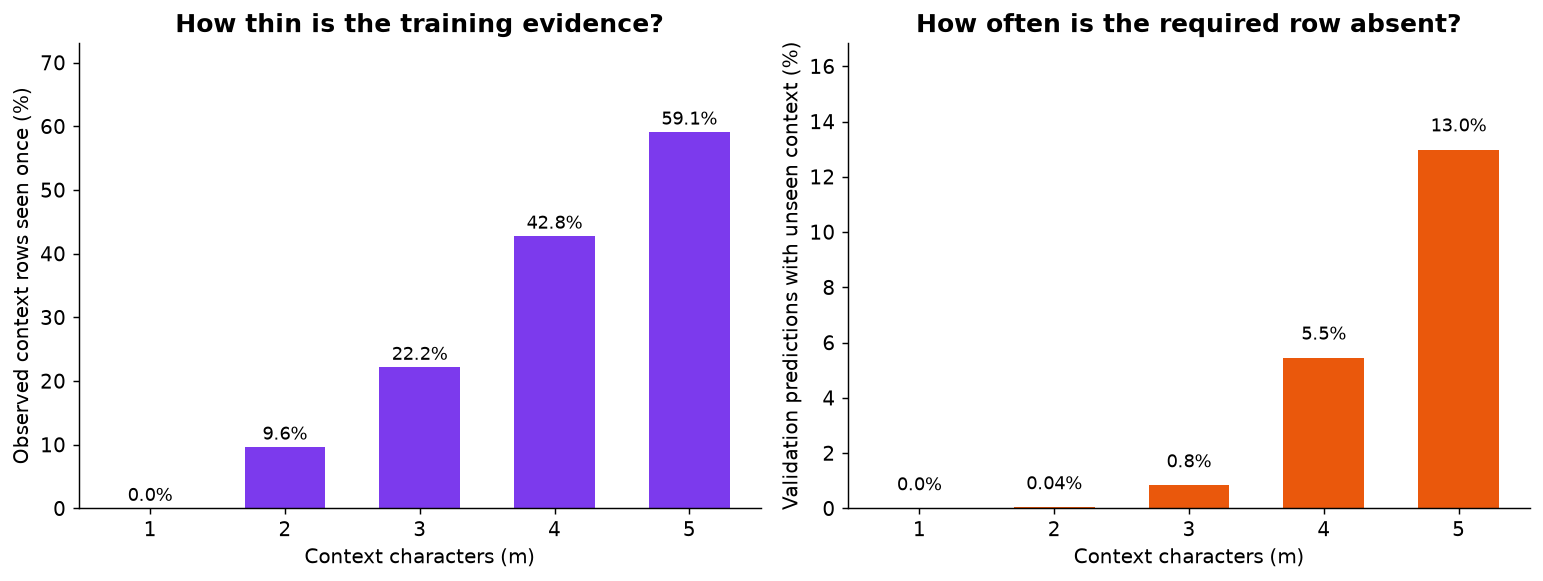

In [14]:
plot_losses(records, OUTPUT)
print("m | singleton rows / observed rows | unseen validation predictions / all predictions")
for r in records:
    v = r["validation"]
    print(f"{r['context_size']} | {r['singleton_rows']:,} / {r['observed_rows']:,}"
          f" | {v['unseen_context_predictions']:,} / {v['predictions']:,}")
plot_evidence(records, OUTPUT)

**Read the denominators:** a singleton is a context row with total count one.
Unseen-context counts are *prediction occurrences*, not distinct missing rows.
The two chart percentages have different denominators and should not be subtracted.

On this dataset and grid, two and then three context characters improve validation
loss. Longer contexts fit training better but validation loss rises. Sparse evidence
supplies a mechanism consistent with those results; these plots do not establish
that every longer-context model or every other smoothing method would fail.

In [15]:
# Read a real held-out query whose context is absent in the longest model.
long_model = models[5]
missing = next((name, c, t) for name in validation_names
               for c, t in windows(name, 5) if c not in long_model.totals)
name, context, target = missing
print("Validation name:", name, "context:", context, "actual target:", target)
print("Stored row?", context in long_model.counts)
print("Raw probability:", long_model.probability(context, target, 0))
print("Smoothed probability:", long_model.probability(context, target, 0.1), "= 1/27")

Validation name: jarek context: ('j', 'a', 'r', 'e', 'k') actual target: <END>
Stored row? False
Raw probability: None
Smoothed probability: 0.037037037037037035 = 1/27


## 10 · Generate without cherry-picking
Show the first 12 samples for every model using seed 2026 and its validation-selected k.
Do not discard odd, empty, repeated, or capped strings. Training membership is a label,
not a score: a plausible familiar name is not proof of generalization.

In [16]:
sample_batches = {}
for r in records:
    m, k = r["context_size"], r["selected_k"]
    rng = random.Random(2026)
    batch = [generate(models[m], k, rng) for _ in range(12)]
    for sample in batch:
        sample["in_training"] = sample["name"] in training_spellings
    sample_batches[str(m)] = batch
    print(f"\nm={m}, k={k:g} — first 12 samples")
    for sample in batch:
        print(f"{sample['name']!r:26}", "END" if sample['ended'] else "CAP",
              "| training spelling:", sample["in_training"])


m=1, k=0.3 — first 12 samples
'ann'                      END | training spelling: True
'aiootlostomia'            END | training spelling: False
'jorole'                   END | training spelling: False
'vi'                       END | training spelling: False
'kamifi'                   END | training spelling: False
'miavenionan'              END | training spelling: False
'li'                       END | training spelling: False
'de'                       END | training spelling: False
'jeajadozarine'            END | training spelling: False
'men'                      END | training spelling: False
'zin'                      END | training spelling: True
'ezen'                     END | training spelling: False

m=2, k=0.3 — first 12 samples
'amiyah'                   END | training spelling: True
'kin'                      END | training spelling: False
'prickeson'                END | training spelling: False
'mak'                      END | training spelling: False
'vi'         

## 11 · Freeze choices, then report test performance
Training counts remain unchanged. Do not retrain on validation for this comparison:
we want the same training set as Episode 01. The selection file records all settings
before the next cell computes test losses. Do not tune against those losses afterward.

Episode 01 already reported a bigram score on this same test split. It remains excluded
from this episode's fitting and selection, but it is **not a newly collected independent
test set**. Re-running fixed code verifies reproducibility; it is not new evidence.

In [17]:
frozen = {
    "dataset_sha256": provenance["sha256"], "split_seed": 42,
    "context_candidates": list(CONTEXT_SIZES), "k_candidates": list(K_VALUES),
    "selected_k_by_context": {str(r["context_size"]): r["selected_k"] for r in records},
    "chosen_context": selected["context_size"], "chosen_k": selected["selected_k"],
    "selection_metric": "validation NLL; first candidate breaks ties",
    "test_policy": "report all fixed candidates; no reselection from test",
}
(OUTPUT / "frozen_selection.json").write_text(json.dumps(frozen, indent=2) + "\n")
print(json.dumps(frozen, indent=2))

{
  "dataset_sha256": "0a30b5557f192f32ab962680889aac5f6fda0f4cecf40a6d0b5694f58ea8cc4d",
  "split_seed": 42,
  "context_candidates": [
    1,
    2,
    3,
    4,
    5
  ],
  "k_candidates": [
    0,
    0.001,
    0.01,
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
    10.0,
    100.0
  ],
  "selected_k_by_context": {
    "1": 0.3,
    "2": 0.3,
    "3": 0.1,
    "4": 0.1,
    "5": 0.1
  },
  "chosen_context": 3,
  "chosen_k": 0.1,
  "selection_metric": "validation NLL; first candidate breaks ties",
  "test_policy": "report all fixed candidates; no reselection from test"
}


In [18]:
test_results = {}
for m in CONTEXT_SIZES:
    k = frozen["selected_k_by_context"][str(m)]
    result = evaluate(models[m], test_names, k)
    assert result["predictions"] == sum(len(n)+1 for n in test_names)
    test_results[str(m)] = {"k": k, **result}
    label = " <- selected by validation" if m == frozen["chosen_context"] else ""
    print(f"m={m}, k={k:g}: test NLL={result['nll']:.6f} "
          f"({result['predictions']:,} predictions){label}")
print("Uniform reference NLL:", math.log(len(models[1].outcomes)))
print("Bigram continuity: Episode 01 test NLL was approximately 2.460499.")

m=1, k=0.3: test NLL=2.460499 (21,053 predictions)
m=2, k=0.3: test NLL=2.238901 (21,053 predictions)
m=3, k=0.1: test NLL=2.129940 (21,053 predictions) <- selected by validation
m=4, k=0.1: test NLL=2.195605 (21,053 predictions)
m=5, k=0.1: test NLL=2.386533 (21,053 predictions)
Uniform reference NLL: 3.295836866004329
Bigram continuity: Episode 01 test NLL was approximately 2.460499.


**What we learned:** 

- We started with a bigram model and gave it more context. Initially, that helped—but more context didn’t keep improving the model.
- Every model had the same training data. 
- Longer contexts divided that evidence into more specific rows, leaving many with just one observation—or none when predicting unseen names.
- Smoothing prevented zero probabilities, but it couldn’t create the missing evidence.
- We used validation to choose context length and smoothing, then checked our choice on test. In this experiment, three characters of context worked best.
- The takeaway is: more context can help, but the model needs enough evidence to use it well. So we want enough evidence per row, and enough different rows covered.